# Student 3 — Defect Detection
## Notebook 00: Dataset Preparation

**Purpose.** This notebook converts the `Clean_Dataset` (preprocessed PCB images + PASCAL VOC
annotations) into the two dataset formats required by the three defect detection algorithms
described in Section 2.4 of the assignment documentation:

| Format | Produced for | Used by |
|---|---|---|
| YOLO (`.txt` labels + `data.yaml`) | Ultralytics | `01_yolov10_training.ipynb`, `03_rtdetr_training.ipynb` |
| COCO (`.json`) | torchvision | `02_faster_rcnn_training.ipynb` |

**Important detail.** The images inside `Clean_Dataset` have been resized to **512 x 512** by the
preprocessing stage (Student 1), but the VOC XML files still store the **original** image
dimensions (e.g. 3034 x 1586) and the bounding boxes in original pixel coordinates. Every box must
therefore be **rescaled** by `sx = 512 / original_width` and `sy = 512 / original_height` before it
can be used for training. This notebook performs that rescaling and visually verifies it.

Run this notebook **first** — the three training notebooks all read the dataset it produces.

### 1. Imports and configuration

Standard library only (plus NumPy / Matplotlib / OpenCV / Pillow) — no deep learning framework is
needed for data preparation. `RANDOM_SEED` fixes the train/validation/test split so that all three
models are trained and evaluated on exactly the same images, which is what makes the comparison in
notebook 04 fair.

In [1]:
import json, random, shutil, sys, warnings
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

warnings.filterwarnings("ignore")
random.seed(0)

# ---------------------------------------------------------------- configuration
RANDOM_SEED  = 42          # fixed seed -> identical split for every model
SPLIT_RATIO  = (0.70, 0.20, 0.10)   # train / val / test
TARGET_SIZE  = 512         # size of the images inside Clean_Dataset

# The six PCB defect classes (Section 2.4 of the documentation).
CLASS_NAMES = [
    "missing_hole",
    "mouse_bite",
    "open_circuit",
    "short",
    "spur",
    "spurious_copper",
]
CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}   # 0-based, YOLO convention

print("Classes:", CLASS_NAMES)

Classes: ['missing_hole', 'mouse_bite', 'open_circuit', 'short', 'spur', 'spurious_copper']


### 2. Locate the dataset

The notebook is expected to live in `Image-Processing/Student3-Defect Detection/`. The cell below
walks up the directory tree until it finds a folder that contains `Clean_Dataset`, so the notebook
also works if it is opened from a different working directory (e.g. Jupyter started at the user
home folder). All generated artefacts are written into `Student3-Defect Detection/dataset/`.

In [2]:
def find_project_root(start: Path) -> Path:
    """Walk upwards from *start* until a directory containing Clean_Dataset is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "Clean_Dataset").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate 'Clean_Dataset'. Set PROJECT_ROOT manually in this cell."
    )

NB_DIR       = Path.cwd()
PROJECT_ROOT = find_project_root(NB_DIR)
CLEAN_DIR    = PROJECT_ROOT / "Clean_Dataset"
ANNOT_DIR    = CLEAN_DIR / "Annotations"

# Output locations (everything Student 3 generates stays inside this student's folder)
WORK_DIR     = PROJECT_ROOT / "Student3-Defect Detection"
DATASET_DIR  = WORK_DIR / "dataset"
YOLO_DIR     = DATASET_DIR / "yolo"
COCO_DIR     = DATASET_DIR / "coco"
RESULTS_DIR  = WORK_DIR / "results"
for d in (DATASET_DIR, YOLO_DIR, COCO_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Clean dataset:", CLEAN_DIR)
print("Output folder:", DATASET_DIR)

Project root : C:\Users\User\Image-Processing
Clean dataset: C:\Users\User\Image-Processing\Clean_Dataset
Output folder: C:\Users\User\Image-Processing\Student3-Defect Detection\dataset


### 3. Inventory — pair every image with its annotation

`Clean_Dataset` stores images in one folder per defect type and the matching VOC XML files under
`Annotations/<Defect_Type>/`. Here every `.jpg` is matched to its `.xml` by file stem, and any
unpaired file is reported so that silent data loss cannot happen later.

In [3]:
records = []          # list of dicts: {stem, image_path, xml_path, folder}
missing_xml, missing_img = [], []

defect_folders = sorted(p for p in CLEAN_DIR.iterdir()
                        if p.is_dir() and p.name != "Annotations")

for folder in defect_folders:
    for img_path in sorted(folder.glob("*.jpg")):
        xml_path = ANNOT_DIR / folder.name / (img_path.stem + ".xml")
        if xml_path.exists():
            records.append({"stem": img_path.stem, "image_path": img_path,
                            "xml_path": xml_path, "folder": folder.name})
        else:
            missing_xml.append(img_path.name)

for xml_path in sorted(ANNOT_DIR.glob("*/*.xml")):
    if not (CLEAN_DIR / xml_path.parent.name / (xml_path.stem + ".jpg")).exists():
        missing_img.append(xml_path.name)

print(f"Defect folders     : {[f.name for f in defect_folders]}")
print(f"Paired samples     : {len(records)}")
print(f"Images without XML : {len(missing_xml)}")
print(f"XML without image  : {len(missing_img)}")
assert records, "No image/annotation pairs were found - check the paths above."

Defect folders     : ['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']
Paired samples     : 693
Images without XML : 0
XML without image  : 0


### 4. VOC parser with coordinate rescaling

`parse_voc()` reads one XML file and returns the class ids and bounding boxes **already rescaled**
to the 512 x 512 image. The scale factors are taken from the `<size>` element of the XML (original
dimensions) and the true size of the JPG on disk, so the code stays correct even if the
preprocessing stage later changes the target resolution. Boxes are clipped to the image and
degenerate boxes (zero width or height after rounding) are dropped.

In [4]:
def parse_voc(xml_path: Path, img_w: int, img_h: int):
    """Return (labels, boxes_xyxy) rescaled to the actual (img_w, img_h) of the JPG."""
    root = ET.parse(xml_path).getroot()
    size = root.find("size")
    orig_w, orig_h = int(size.find("width").text), int(size.find("height").text)
    sx, sy = img_w / orig_w, img_h / orig_h

    labels, boxes = [], []
    for obj in root.findall("object"):
        name = obj.find("name").text.strip().lower()
        if name not in CLASS_TO_ID:
            print(f"  ! unknown class '{name}' in {xml_path.name} - skipped")
            continue
        bb = obj.find("bndbox")
        x1 = float(bb.find("xmin").text) * sx
        y1 = float(bb.find("ymin").text) * sy
        x2 = float(bb.find("xmax").text) * sx
        y2 = float(bb.find("ymax").text) * sy
        # clip to the image and enforce x1<x2, y1<y2
        x1, x2 = sorted((max(0.0, min(x1, img_w)), max(0.0, min(x2, img_w))))
        y1, y2 = sorted((max(0.0, min(y1, img_h)), max(0.0, min(y2, img_h))))
        if x2 - x1 < 1 or y2 - y1 < 1:
            continue
        labels.append(CLASS_TO_ID[name])
        boxes.append([x1, y1, x2, y2])
    return labels, boxes


# Parse the whole dataset once and cache the result in `records`
for r in records:
    with Image.open(r["image_path"]) as im:
        r["width"], r["height"] = im.size
    r["labels"], r["boxes"] = parse_voc(r["xml_path"], r["width"], r["height"])

n_boxes = sum(len(r["labels"]) for r in records)
img_sizes = Counter((r["width"], r["height"]) for r in records)
print(f"Parsed {len(records)} images / {n_boxes} bounding boxes")
print(f"Average boxes per image: {n_boxes / len(records):.2f}")
print("Image sizes on disk    :", dict(img_sizes))

Parsed 693 images / 2953 bounding boxes
Average boxes per image: 4.26
Image sizes on disk    : {(512, 512): 693}


### 5. Annotation statistics

The class balance and the distribution of defect sizes determine how difficult the detection task
is. PCB defects are **small objects** — the plot below shows that most boxes occupy well under 1 %
of the image area, which is exactly the regime in which the three architectures differ most
(Section 2.4.4 of the documentation).

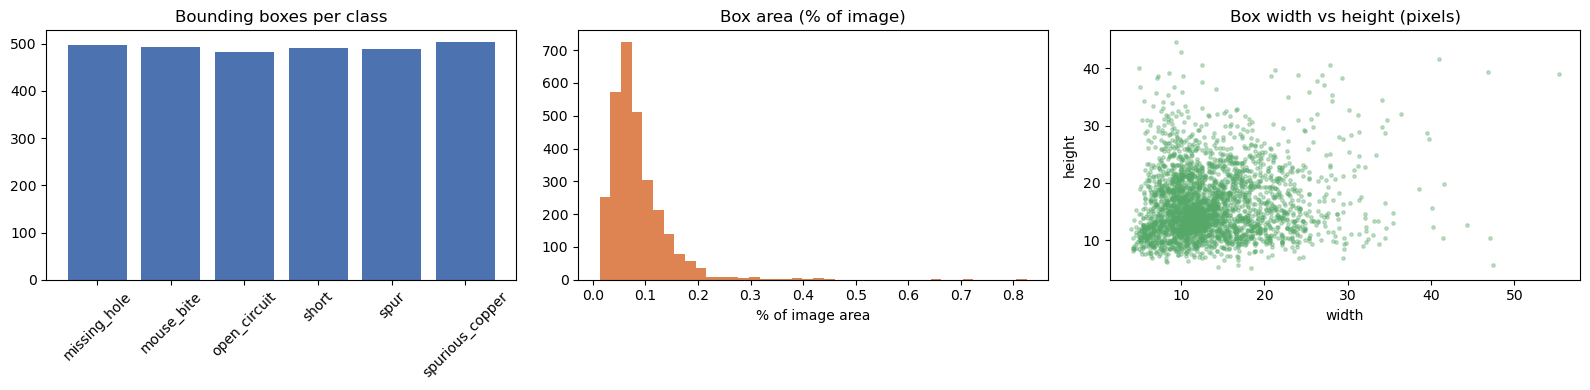

Boxes per class: {'missing_hole': 497, 'mouse_bite': 492, 'open_circuit': 482, 'short': 491, 'spur': 488, 'spurious_copper': 503}
Median box: 12.1 x 15.0 px (0.072 % of the image)


In [5]:
class_counts = Counter()
areas, widths, heights = [], [], []
for r in records:
    for lab, (x1, y1, x2, y2) in zip(r["labels"], r["boxes"]):
        class_counts[CLASS_NAMES[lab]] += 1
        widths.append(x2 - x1)
        heights.append(y2 - y1)
        areas.append((x2 - x1) * (y2 - y1) / (r["width"] * r["height"]) * 100)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].bar(list(class_counts), [class_counts[c] for c in class_counts], color="#4C72B0")
ax[0].set_title("Bounding boxes per class"); ax[0].tick_params(axis="x", rotation=45)
ax[1].hist(areas, bins=40, color="#DD8452")
ax[1].set_title("Box area (% of image)"); ax[1].set_xlabel("% of image area")
ax[2].scatter(widths, heights, s=6, alpha=.35, color="#55A868")
ax[2].set_title("Box width vs height (pixels)"); ax[2].set_xlabel("width"); ax[2].set_ylabel("height")
plt.tight_layout(); plt.show()

print("Boxes per class:", dict(class_counts))
print(f"Median box: {np.median(widths):.1f} x {np.median(heights):.1f} px "
      f"({np.median(areas):.3f} % of the image)")

### 6. Visual verification of the rescaled boxes

This is the single most important sanity check in the notebook: if the rescaling in Section 4 were
wrong, the boxes would sit in the wrong place and every model would train on noise. One sample per
defect class is drawn with its rescaled boxes.

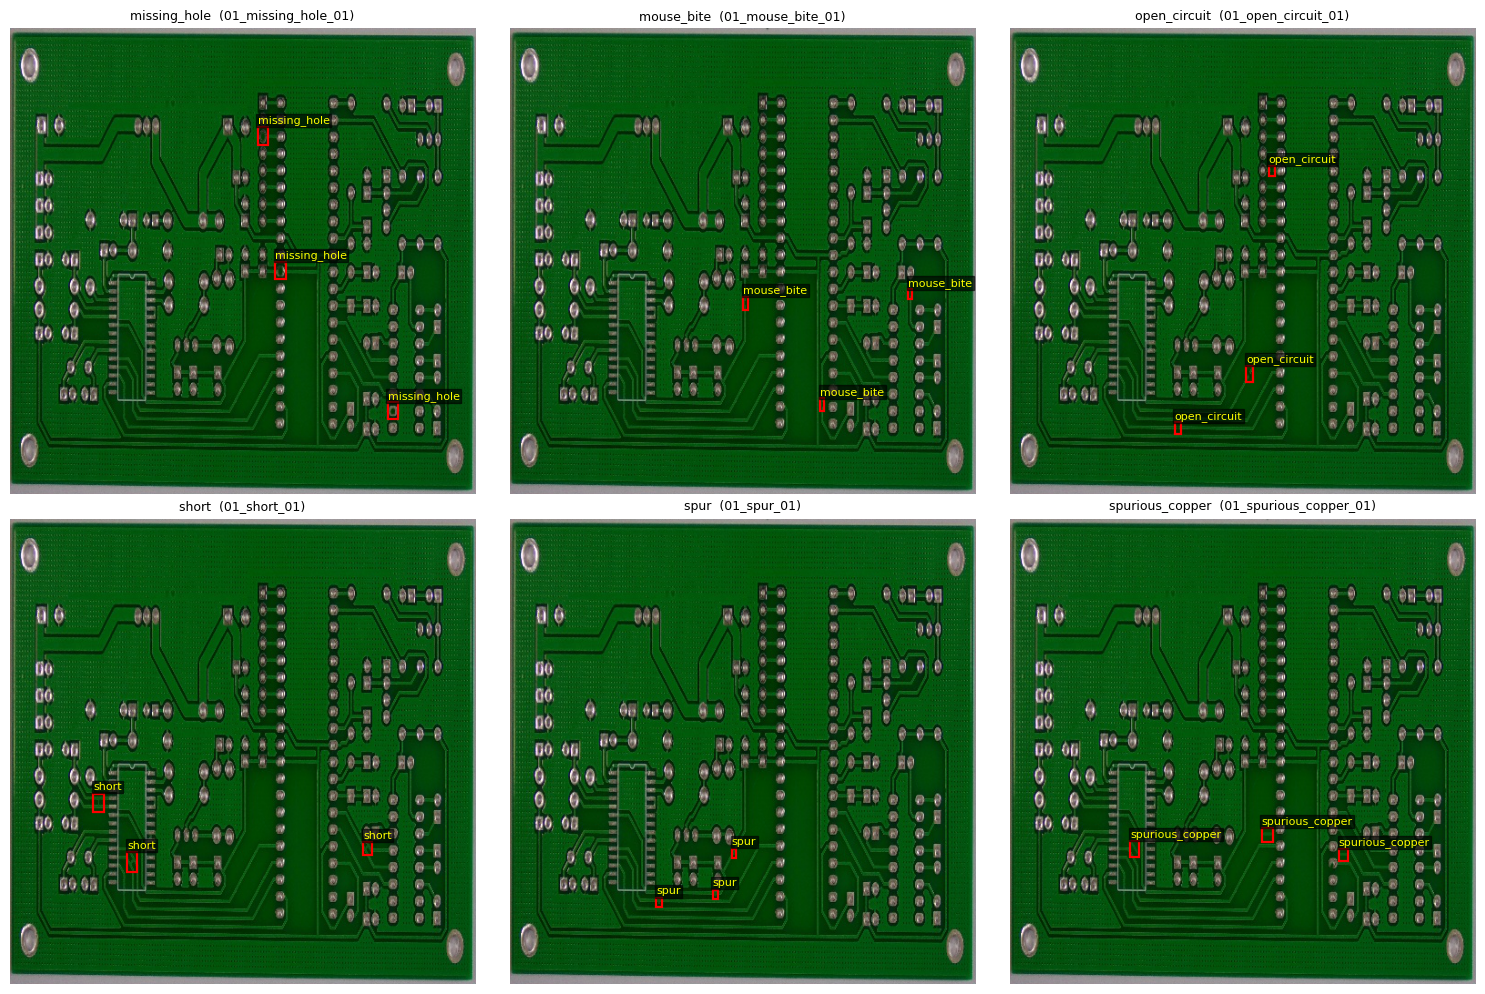

In [6]:
one_per_class = {}
for r in records:
    if r["labels"]:
        key = CLASS_NAMES[r["labels"][0]]
        one_per_class.setdefault(key, r)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (cls, r) in zip(axes.ravel(), sorted(one_per_class.items())):
    ax.imshow(Image.open(r["image_path"]))
    for lab, (x1, y1, x2, y2) in zip(r["labels"], r["boxes"]):
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                   fill=False, edgecolor="red", linewidth=1.6))
        ax.text(x1, max(y1 - 4, 8), CLASS_NAMES[lab], color="yellow", fontsize=8,
                bbox=dict(facecolor="black", alpha=.6, pad=1))
    ax.set_title(f"{cls}  ({r['stem']})", fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

### 7. Stratified train / validation / test split

Each image is assigned to the class of the defect it contains (every image in this dataset contains
one defect type only) and the split is performed **within** each class, so the 70 / 20 / 10 ratio
holds for every defect type. The seed is fixed, and the resulting file lists are saved to disk so
the exact same split is reused by all three models.

In [7]:
rng = random.Random(RANDOM_SEED)
by_class = defaultdict(list)
for r in records:
    key = CLASS_NAMES[r["labels"][0]] if r["labels"] else "background"
    by_class[key].append(r)

splits = {"train": [], "val": [], "test": []}
for cls, items in sorted(by_class.items()):
    items = sorted(items, key=lambda x: x["stem"])
    rng.shuffle(items)
    n = len(items)
    n_train = int(round(n * SPLIT_RATIO[0]))
    n_val   = int(round(n * SPLIT_RATIO[1]))
    splits["train"] += items[:n_train]
    splits["val"]   += items[n_train:n_train + n_val]
    splits["test"]  += items[n_train + n_val:]

print(f"{'class':<18}{'train':>7}{'val':>7}{'test':>7}")
for cls in sorted(by_class):
    row = [sum(1 for r in splits[s] if (CLASS_NAMES[r['labels'][0]] if r['labels'] else 'background') == cls)
           for s in ("train", "val", "test")]
    print(f"{cls:<18}{row[0]:>7}{row[1]:>7}{row[2]:>7}")
print(f"{'TOTAL':<18}{len(splits['train']):>7}{len(splits['val']):>7}{len(splits['test']):>7}")

class               train    val   test
missing_hole           80     23     12
mouse_bite             80     23     12
open_circuit           81     23     12
short                  81     23     12
spur                   80     23     12
spurious_copper        81     23     12
TOTAL                 483    138     72


### 8. Export — YOLO format (for YOLOv10 and RT-DETR)

Ultralytics expects `images/<split>/x.jpg` next to `labels/<split>/x.txt`, where each line is
`class_id cx cy w h` with all four coordinates **normalised to [0, 1]**. The images are copied
(not moved) so that `Clean_Dataset` is never modified. A `data.yaml` describing the paths and the
class names is written at the end.

In [8]:
def to_yolo_line(label, box, w, h):
    x1, y1, x2, y2 = box
    cx, cy = (x1 + x2) / 2 / w, (y1 + y2) / 2 / h
    bw, bh = (x2 - x1) / w, (y2 - y1) / h
    return f"{label} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}"


for split, items in splits.items():
    img_out = YOLO_DIR / "images" / split
    lbl_out = YOLO_DIR / "labels" / split
    for d in (img_out, lbl_out):
        d.mkdir(parents=True, exist_ok=True)
        for old in d.glob("*"):
            old.unlink()
    for r in items:
        shutil.copy2(r["image_path"], img_out / f"{r['stem']}.jpg")
        lines = [to_yolo_line(l, b, r["width"], r["height"])
                 for l, b in zip(r["labels"], r["boxes"])]
        (lbl_out / f"{r['stem']}.txt").write_text("\n".join(lines), encoding="utf-8")
    print(f"{split:<6} -> {len(items):3d} images, "
          f"{sum(len(r['labels']) for r in items):4d} boxes")

data_yaml = YOLO_DIR / "data.yaml"
data_yaml.write_text(
    "# PCB defect detection - auto-generated by 00_data_preparation.ipynb\n"
    f"path: {YOLO_DIR.as_posix()}\n"
    "train: images/train\n"
    "val: images/val\n"
    "test: images/test\n"
    f"nc: {len(CLASS_NAMES)}\n"
    "names:\n" + "".join(f"  {i}: {n}\n" for i, n in enumerate(CLASS_NAMES)),
    encoding="utf-8")
print("\nWrote", data_yaml)
print(data_yaml.read_text())

train  -> 483 images, 2051 boxes
val    -> 138 images,  598 boxes
test   ->  72 images,  304 boxes

Wrote C:\Users\User\Image-Processing\Student3-Defect Detection\dataset\yolo\data.yaml
# PCB defect detection - auto-generated by 00_data_preparation.ipynb
path: C:/Users/User/Image-Processing/Student3-Defect Detection/dataset/yolo
train: images/train
val: images/val
test: images/test
nc: 6
names:
  0: missing_hole
  1: mouse_bite
  2: open_circuit
  3: short
  4: spur
  5: spurious_copper



### 9. Export — COCO format (for Faster R-CNN)

torchvision's detection models are trained from COCO-style JSON. Note the two conventions that
differ from YOLO: boxes are stored as **absolute `[x, y, width, height]`**, and category ids start
at **1** because id 0 is reserved for the background class in torchvision. The JSON files reference
the images that were copied in Section 8, so the images are not duplicated on disk.

In [9]:
COCO_DIR.mkdir(parents=True, exist_ok=True)
categories = [{"id": i + 1, "name": n, "supercategory": "pcb_defect"}
              for i, n in enumerate(CLASS_NAMES)]

for split, items in splits.items():
    images, annotations, ann_id = [], [], 1
    for img_id, r in enumerate(items, start=1):
        images.append({"id": img_id, "file_name": f"{r['stem']}.jpg",
                       "width": r["width"], "height": r["height"]})
        for lab, (x1, y1, x2, y2) in zip(r["labels"], r["boxes"]):
            annotations.append({
                "id": ann_id, "image_id": img_id,
                "category_id": lab + 1,                       # 1-based for torchvision
                "bbox": [round(x1, 2), round(y1, 2), round(x2 - x1, 2), round(y2 - y1, 2)],
                "area": round((x2 - x1) * (y2 - y1), 2),
                "iscrowd": 0,
            })
            ann_id += 1
    payload = {"info": {"description": "PCB defect detection (Clean_Dataset)"},
               "images": images, "annotations": annotations, "categories": categories}
    out = COCO_DIR / f"instances_{split}.json"
    out.write_text(json.dumps(payload), encoding="utf-8")
    print(f"{out.name:<24} {len(images):3d} images, {len(annotations):4d} annotations")

instances_train.json     483 images, 2051 annotations
instances_val.json       138 images,  598 annotations
instances_test.json       72 images,  304 annotations


### 10. Save the dataset manifest

`dataset_info.json` records the class list, the split sizes and the paths that the three training
notebooks need. It is the only file the other notebooks have to read in order to stay consistent
with this preparation step.

In [10]:
info = {
    "class_names": CLASS_NAMES,
    "num_classes": len(CLASS_NAMES),
    "image_size": TARGET_SIZE,
    "random_seed": RANDOM_SEED,
    "split_ratio": list(SPLIT_RATIO),
    "counts": {s: len(v) for s, v in splits.items()},
    "boxes": {s: sum(len(r["labels"]) for r in v) for s, v in splits.items()},
    "paths": {
        "yolo_root": YOLO_DIR.as_posix(),
        "yolo_yaml": (YOLO_DIR / "data.yaml").as_posix(),
        "coco_dir":  COCO_DIR.as_posix(),
        "results_dir": RESULTS_DIR.as_posix(),
    },
    "files": {s: [r["stem"] for r in v] for s, v in splits.items()},
}
(DATASET_DIR / "dataset_info.json").write_text(json.dumps(info, indent=2), encoding="utf-8")
print(json.dumps({k: v for k, v in info.items() if k != "files"}, indent=2))

{
  "class_names": [
    "missing_hole",
    "mouse_bite",
    "open_circuit",
    "short",
    "spur",
    "spurious_copper"
  ],
  "num_classes": 6,
  "image_size": 512,
  "random_seed": 42,
  "split_ratio": [
    0.7,
    0.2,
    0.1
  ],
  "counts": {
    "train": 483,
    "val": 138,
    "test": 72
  },
  "boxes": {
    "train": 2051,
    "val": 598,
    "test": 304
  },
  "paths": {
    "yolo_root": "C:/Users/User/Image-Processing/Student3-Defect Detection/dataset/yolo",
    "yolo_yaml": "C:/Users/User/Image-Processing/Student3-Defect Detection/dataset/yolo/data.yaml",
    "coco_dir": "C:/Users/User/Image-Processing/Student3-Defect Detection/dataset/coco",
    "results_dir": "C:/Users/User/Image-Processing/Student3-Defect Detection/results"
  }
}


### 11. Final verification

The last check re-reads the exported files **from disk** (not from memory) and redraws the boxes of
one training image from its YOLO label and one from its COCO entry. If both drawings match the
defect locations, the exported dataset is correct and training can begin.

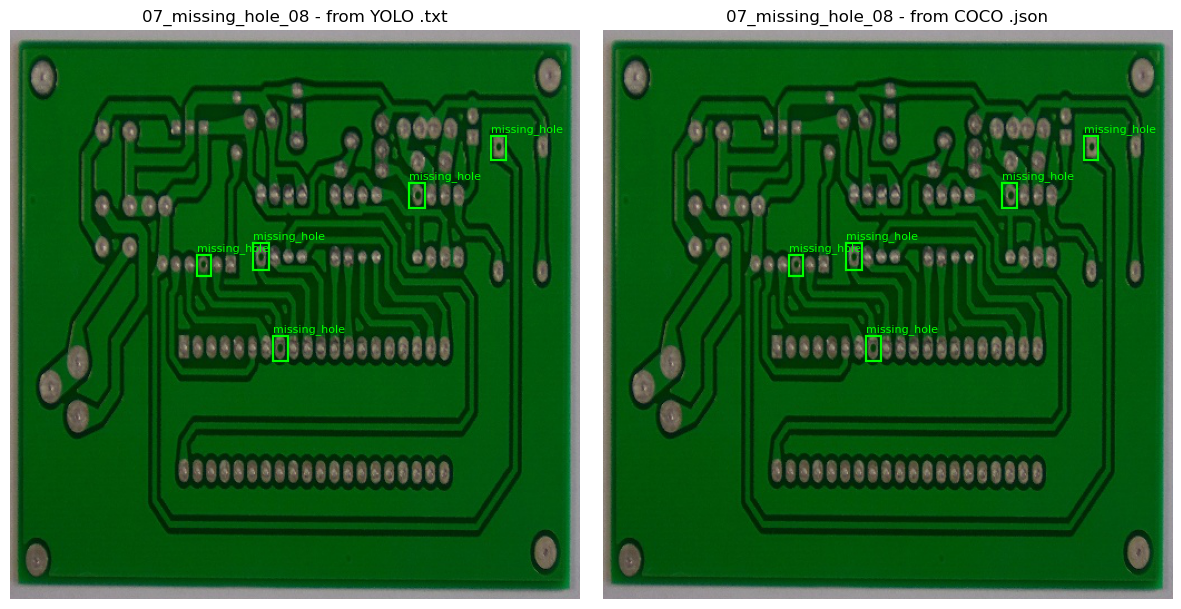

OK - 5 boxes match between the two export formats.

Dataset preparation complete. Next: 01_yolov10_training.ipynb


In [11]:
# --- verify a YOLO label -------------------------------------------------
stem = splits["train"][0]["stem"]
img = Image.open(YOLO_DIR / "images/train" / f"{stem}.jpg"); W, H = img.size
yolo_boxes = []
for line in (YOLO_DIR / "labels/train" / f"{stem}.txt").read_text().split("\n"):
    if not line.strip():
        continue
    c, cx, cy, bw, bh = line.split()
    cx, cy, bw, bh = float(cx) * W, float(cy) * H, float(bw) * W, float(bh) * H
    yolo_boxes.append((int(c), cx - bw / 2, cy - bh / 2, bw, bh))

# --- verify a COCO entry -------------------------------------------------
coco = json.loads((COCO_DIR / "instances_train.json").read_text())
img_rec = next(i for i in coco["images"] if i["file_name"] == f"{stem}.jpg")
coco_boxes = [(a["category_id"] - 1, *a["bbox"])
              for a in coco["annotations"] if a["image_id"] == img_rec["id"]]

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for a, boxes, title in ((ax[0], yolo_boxes, "from YOLO .txt"), (ax[1], coco_boxes, "from COCO .json")):
    a.imshow(img)
    for c, x, y, w, h in boxes:
        a.add_patch(plt.Rectangle((x, y), w, h, fill=False, edgecolor="lime", linewidth=1.6))
        a.text(x, max(y - 4, 8), CLASS_NAMES[c], color="lime", fontsize=8)
    a.set_title(f"{stem} - {title}"); a.axis("off")
plt.tight_layout(); plt.show()

assert len(yolo_boxes) == len(coco_boxes), "YOLO and COCO exports disagree on the box count!"
print(f"OK - {len(yolo_boxes)} boxes match between the two export formats.")
print("\nDataset preparation complete. Next: 01_yolov10_training.ipynb")